# 📊 Análise de Correspondência Simples (ANACOR)

Este notebook apresenta uma **Análise de Correspondência Simples (ANACOR)** aplicada a dados de perfil de investimento e tipo de aplicação financeira, com o objetivo de identificar **associações entre categorias**.

## 📦 Importação das Bibliotecas

Nesta etapa, importamos as bibliotecas necessárias para manipulação de dados, testes estatísticos e visualização.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import prince

## 🔍 1. Leitura da Base e Análise Exploratória (EDA)

Aqui realizamos a leitura do conjunto de dados e observamos as distribuições das variáveis categóricas.

In [ ]:
# Ajuste o caminho conforme a sua estrutura de pastas
perfil = pd.read_excel("data/perfil_aplicacao.xlsx")

print(perfil['Perfil'].value_counts())
print(perfil['Tipo de Aplicação'].value_counts())

tabela = pd.crosstab(perfil['Perfil'], perfil['Tipo de Aplicação'])
print(tabela)

Perfil
Agressivo      58
Moderado       25
Conservador    17
Name: count, dtype: int64
Tipo de Aplicação
Ações       45
CDB         40
Poupança    15
Name: count, dtype: int64
Tipo de Aplicação  Ações  CDB  Poupança
Perfil                                 
Agressivo             36   20         2
Conservador            5    4         8
Moderado               4   16         5


## 📐 2. Teste Qui-Quadrado de Independência

O teste qui-quadrado é utilizado para verificar se existe associação estatisticamente significativa entre as variáveis categóricas.

In [5]:
chi2, p_valor, dof, esperados = chi2_contingency(tabela)

print('Qui-quadrado:', chi2)
print('p-valor:', p_valor)
print('Graus de liberdade:', dof)
print('Valores Esperados:\n', esperados)

Qui-quadrado: 31.764164976335362
p-valor: 2.137594051381398e-06
Graus de liberdade: 4
Valores Esperados:
 [[26.1  23.2   8.7 ]
 [ 7.65  6.8   2.55]
 [11.25 10.    3.75]]


## 📊 3. Resíduos Padronizados Ajustados

Os resíduos padronizados ajustados indicam quais combinações de categorias apresentam associação estatisticamente significativa.

|resíduo| > 1,96 → associação estatisticamente significativa

Tipo de Aplicação     Ações       CDB  Poupança
Perfil                                         
Agressivo          4.031893 -1.323444 -3.801728
Conservador       -1.418061 -1.521559  4.063291
Moderado          -3.365501  2.828427  0.808452


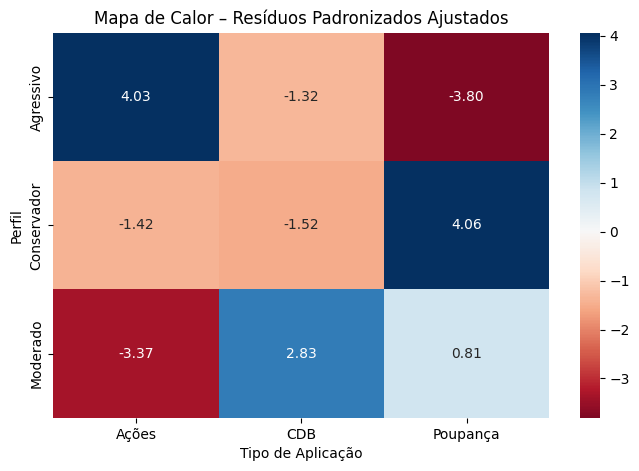

In [6]:
tab_cont = sm.stats.Table(tabela)
residuos = tab_cont.standardized_resids
print(residuos)

plt.figure(figsize=(8,5))
sns.heatmap(residuos, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Mapa de Calor – Resíduos Padronizados Ajustados')
plt.show()

🔎 Principais Resultados

Os resíduos padronizados ajustados indicaram associações estatisticamente significativas, destacando-se:

✔ Perfil agressivo ↔ Ações

✔ Perfil conservador ↔ Poupança

✔ Perfil moderado ↔ CDB

Uma vez que essas combinações apresentaram resíduos padronizados ajustados superiores a 1,96.

## 🧭 4. Análise de Correspondência Simples (ANACOR)

Nesta etapa, ajustamos o modelo de Análise de Correspondência à tabela de contingência, decompondo a associação em dimensões.

In [7]:
ca = prince.CA(n_components=2).fit(tabela)

print(ca.eigenvalues_summary)

          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.233        73.42%                     73.42%
1              0.084        26.58%                    100.00%


## 🗺️ 5. Mapa Percentual da Análise de Correspondência

O mapa percentual permite visualizar graficamente as associações entre categorias. A proximidade entre pontos indica associação.

Representação gráfica das categorias no plano Dimensão 1 × Dimensão 2

Interpretação baseada em:

📍 Distância ao centro → contribuição para a associação

🔗 Proximidade entre pontos → associação entre categorias

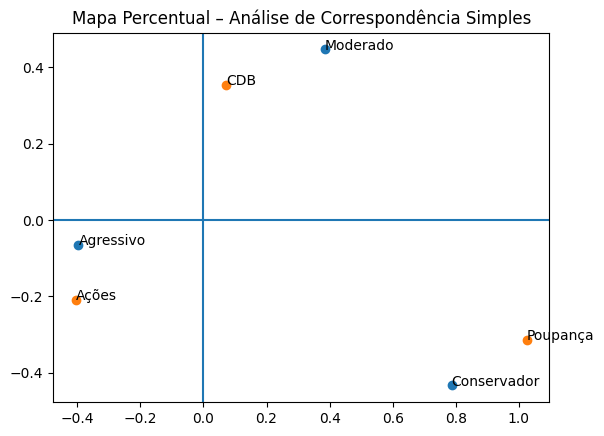

In [8]:
row = ca.row_coordinates(tabela)
col = ca.column_coordinates(tabela)

plt.scatter(row[0], row[1])
plt.scatter(col[0], col[1])

for i in row.index:
    plt.text(row.loc[i, 0], row.loc[i, 1], i)

for i in col.index:
    plt.text(col.loc[i, 0], col.loc[i, 1], i)

plt.axhline(0)
plt.axvline(0)
plt.title('Mapa Percentual – Análise de Correspondência Simples')
plt.show()

## ✅ Conclusão

A Análise de Correspondência evidenciou associações claras entre perfis de investimento e tipos de aplicação financeira. O teste qui-quadrado e os resíduos padronizados confirmaram a significância das associações, enquanto o mapa percentual permitiu visualizar a estrutura relacional entre as categorias.

A predominância da primeira dimensão indica que o principal padrão de associação é bem representado no plano bidimensional, tornando a ANACOR uma ferramenta útil para análise exploratória e apoio à tomada de decisão.

## 🎯 Objetivo Final da Análise de Correspondência (ANACOR)

A Análise de Correspondência Simples (ANACOR) tem como objetivo:

🔗 Identificar associações entre categorias de variáveis categóricas

🧠 Evidenciar padrões de comportamento presentes nos dados

👥 Revelar quais categorias tendem a se associar entre si, mais do que o esperado sob a hipótese de independência

Dessa forma, a ANACOR atua como uma ferramenta exploratória que transforma tabelas de contingência em representações visuais e interpretáveis, apoiando a compreensão de relacionamentos entre categorias e a tomada de decisões baseada em dados.